# VoltFix AI

---

In [2]:
# Importing Necessary Libraries

import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# Loading Data from Simulink

data = loadmat("simulation_data_LG.mat")
Vabc = data["Vabc"]
Iabc = data["Iabc"]
t = data["t"].squeeze()

In [4]:
# Making the DataFrame

df_v = pd.DataFrame()
df_v = pd.DataFrame(Vabc)
df_v.columns = ["Va","Vb","Vc"]

df_c = pd.DataFrame()
df_c = pd.DataFrame(Iabc)
df_c.columns = ["Ia","Ib","Ic"]

df_t = pd.DataFrame()
df_t["Time"] = pd.DataFrame(t) 

df = pd.concat([df_t,df_v,df_c],axis = 1)

df.head()


,Time,Va,Vb,Vc,Ia,Ib,Ic
0,0.00000,-45.272684,-7744.036370,7789.309054,-9.431133,-58.984694,68.415827
1,0.00005,95.598243,-7814.129517,7718.531274,-8.274637,-59.683372,67.958009
2,0.00010,236.446869,-7882.295290,7645.848421,-7.116097,-60.367326,67.483423
3,0.00015,377.235640,-7948.515472,7571.279832,-5.955796,-61.036388,66.992184
4,0.00020,517.932637,-8012.775137,7494.842500,-4.794019,-61.690393,66.484412


In [5]:
# Adding the Neutal Current In

df["In"] = df["Ia"] + df["Ib"] + df["Ic"]
df.loc[df["In"].abs() < 1e-3 ,"In"] = 0
df.head()

,Time,Va,Vb,Vc,Ia,Ib,Ic,In
0,0.00000,-45.272684,-7744.036370,7789.309054,-9.431133,-58.984694,68.415827,0.0
1,0.00005,95.598243,-7814.129517,7718.531274,-8.274637,-59.683372,67.958009,0.0
2,0.00010,236.446869,-7882.295290,7645.848421,-7.116097,-60.367326,67.483423,0.0
3,0.00015,377.235640,-7948.515472,7571.279832,-5.955796,-61.036388,66.992184,0.0
4,0.00020,517.932637,-8012.775137,7494.842500,-4.794019,-61.690393,66.484412,0.0


In [6]:
# Statistical Analysis of the Data

df.describe()

,Time,Va,Vb,Vc,Ia,Ib,Ic,In
count,4001.000000,4001.000000,4001.000000,4001.000000,4001.000000,4001.000000,4001.000000,4001.000000
mean,0.100000,20.077207,6.857043,10.743132,-107.053879,6.138307,6.170226,-94.745346
std,0.057757,6175.082943,6321.018269,6369.411092,564.588189,55.148602,57.846180,536.928643
min,0.000000,-8972.134969,-8972.966364,-9100.167374,-2077.268714,-78.940703,-93.428934,-1977.982081
25%,0.050000,-6109.220784,-6309.667021,-6345.554729,-63.117432,-48.096763,-49.732663,0.000000
50%,0.100000,17.829393,39.843652,-1.684050,-3.467046,6.565723,5.331775,21.617566
75%,0.150000,6169.135289,6307.054316,6378.382448,63.482650,60.266541,61.474222,22.860528
max,0.200000,8968.181127,8969.504553,9177.678636,1355.728618,95.869116,109.137961,1302.232820


In [7]:
# Observing the necessary types 

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4001 entries, 0 to 4000
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    4001 non-null   float64
 1   Va      4001 non-null   float64
 2   Vb      4001 non-null   float64
 3   Vc      4001 non-null   float64
 4   Ia      4001 non-null   float64
 5   Ib      4001 non-null   float64
 6   Ic      4001 non-null   float64
 7   In      4001 non-null   float64
dtypes: float64(8)
memory usage: 250.2 KB


In [8]:
# Checking the Null Values of the data

df.isnull().sum()

Time    0
Va      0
Vb      0
Vc      0
Ia      0
Ib      0
Ic      0
In      0
dtype: int64

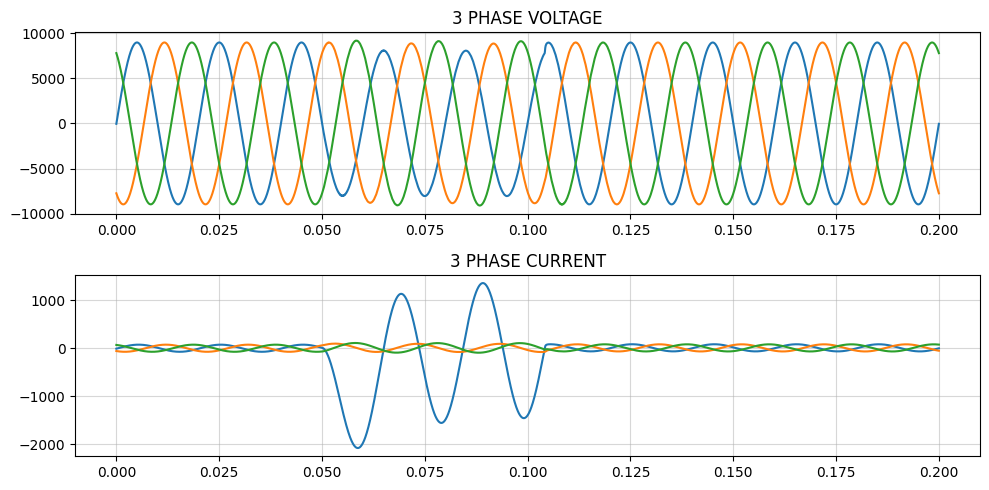

In [9]:
# Basic Visualization of the data gathered

fig,axs = plt.subplots(ncols = 1,nrows = 2,figsize =[10,5])
axs = axs.flatten()
axs[0].plot(t,Vabc)
axs[0].set_title("3 PHASE VOLTAGE")
axs[0].grid(True,alpha = 0.5)

axs[1].plot(t,Iabc)
axs[1].set_title("3 PHASE CURRENT")
axs[1].grid(True,alpha = 0.5)

plt.tight_layout()

In [10]:
# Adding RMS Voltages and Currents 

phases = ["Va","Vb","Vc","Ia","Ib","Ic"]
rms_window = int((1/(5e-05))/50) # Roughly 400
for phase in phases:
    df[f"{phase}_rms"] = np.sqrt((df[phase]**2).rolling(window = 400,center = True).mean())

df["In_rms"] = np.sqrt((df["In"]**2).rolling(window = 400,center = True).mean())
df = df.bfill().ffill() # Rolling creates NAN values for first few samples as not enough samples

df.head()

,Time,Va,Vb,Vc,Ia,Ib,Ic,In,Va_rms,Vb_rms,Vc_rms,Ia_rms,Ib_rms,Ic_rms,In_rms
0,0.00000,-45.272684,-7744.036370,7789.309054,-9.431133,-58.984694,68.415827,0.0,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,0.0
1,0.00005,95.598243,-7814.129517,7718.531274,-8.274637,-59.683372,67.958009,0.0,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,0.0
2,0.00010,236.446869,-7882.295290,7645.848421,-7.116097,-60.367326,67.483423,0.0,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,0.0
3,0.00015,377.235640,-7948.515472,7571.279832,-5.955796,-61.036388,66.992184,0.0,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,0.0
4,0.00020,517.932637,-8012.775137,7494.842500,-4.794019,-61.690393,66.484412,0.0,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,0.0


---

- Firstly, we have made the data that accounts for Line to Ground Fault, so we will do the operation first for LG type of fault. We will provide value 1 if the fault condition has been satisfied.

- Fault condition is generally found by knowing about the current. If the current drawn from the system is greater than a certain threshold value of current then we will say that a fault as occured.

- Point to be noted is that, during the starting of the motor or any such appliance there is the drawing of in rush current so to make our system not consider the inrush current as the fault current we will also compare the logic with the voltage provided.

- But when a fault occurs, then during this condition both current and voltage drop occurs. This logic of comparision of current and voltage makes our AI resistant against differentiating between simple loading and a fault.


In [11]:
# Fault Threshold Operation

threshold_current = 165 # 1.5 times of fault free max current
threshold_voltage = 7200 # 80% of fault free max voltage

df["Fault_State"] = (((df["Ia"].abs() > threshold_current) &
                       (df["Va"].abs() < threshold_voltage))|
                    ((df["Ib"].abs() > threshold_current) 
                     & (df["Vb"].abs() < threshold_voltage)) |
                    ((df["Ic"].abs() > threshold_current) 
                     & (df["Vc"].abs() < threshold_voltage))).astype(int)

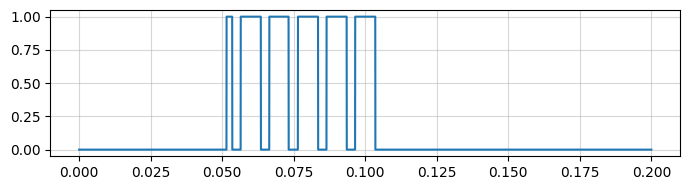

In [12]:
fig,axs = plt.subplots(figsize =[7,2])
axs.plot(t,df["Fault_State"])
axs.grid(True,alpha=0.5)
plt.tight_layout()

- Point to be noted is that, our current is sinosoidal in nature, so it will cross the zero position twice every cycle of AC. During the zero crossing period, current is by nature less than the threshold value so system will conclude it as not fault.

- Our fault column can flicker like 1 ... 0 ... 0 ... 1 and so on. This is not practical, so to
remove this issue we use the concept of RMS current window. We calculate the RMS current and then compare it with the threshold. Even if the current is at zero crossing, its RMS wont flicker as it is the root of mean squarred values.

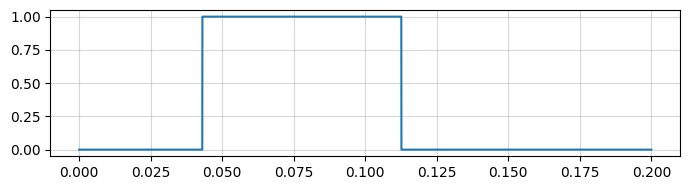

In [13]:
threshold_rms = 120 # Max_Value / root(2)
df["Fault_State"] = (df["Ia_rms"] > threshold_rms).astype(int)

fig,axs = plt.subplots(figsize =[7,2])
axs.plot(t,df["Fault_State"])
axs.grid(True,alpha=0.5)
plt.tight_layout()

- We have done encoding for our fault and healthy system. <Br>
0 - Healthy<Br>
1 -  LG { Line to Ground Fault }<br>
2 -  LL { Line to Line Fault }<Br>
3 - LLL { Three Phase Fault }<BR>

- This Numeric encoding is done so that our model can compute the cost functions and catagorize errors more easily, because we can find mathematically find the error between 0 and 1 rather than "Healthy" and "LG". 


In [14]:
# Adding Fault type Column in DataFrame 

df = df.rename(columns = {"Fault_State" : "Fault_Type"})
fault_map = {0:"Healthy",1:"LG"}
df["Fault_Name"] = df["Fault_Type"].map(fault_map)
df.head()


,Time,Va,Vb,Vc,Ia,Ib,Ic,In,Va_rms,Vb_rms,Vc_rms,Ia_rms,Ib_rms,Ic_rms,In_rms,Fault_Type,Fault_Name
0,0.00000,-45.272684,-7744.036370,7789.309054,-9.431133,-58.984694,68.415827,0.0,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,0.0,0,Healthy
1,0.00005,95.598243,-7814.129517,7718.531274,-8.274637,-59.683372,67.958009,0.0,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,0.0,0,Healthy
2,0.00010,236.446869,-7882.295290,7645.848421,-7.116097,-60.367326,67.483423,0.0,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,0.0,0,Healthy
3,0.00015,377.235640,-7948.515472,7571.279832,-5.955796,-61.036388,66.992184,0.0,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,0.0,0,Healthy
4,0.00020,517.932637,-8012.775137,7494.842500,-4.794019,-61.690393,66.484412,0.0,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,0.0,0,Healthy


- Our machine learning model, if fed with raw values of current and voltage, then due to the sine nature of the wave, it can disturb the learning process and can hinder the accuracy of the model's prediction.

- To prevent this core issue we are doing feature engineering, we are adding new features of RMS currents and voltages for each phase so that our model can learn to detect faults much more easily.

- RMS value for any wave form is computed on full cycle of the wave, so to match this and prevent any other problem, we must select the window range for rms value such that it has occupies the full cycle of our wave form

- For our RMS value to be exact, we have sampling time period of 50 micro sec and then system frequency of 50 Hz as in the simulink part.

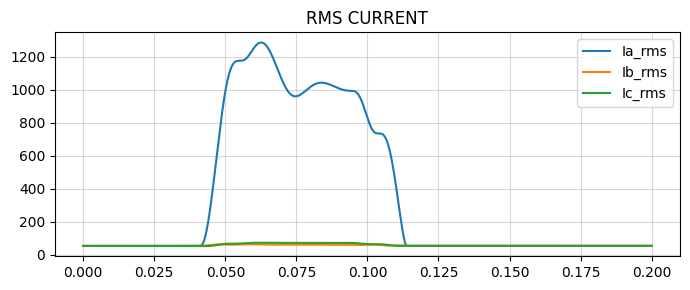

In [15]:
# RMS CURRENT VISUALIZATION 

fig,axs = plt.subplots(figsize=[7,3])
axs = axs
axs.set_title("RMS CURRENT")
axs.plot(df["Time"],df["Ia_rms"],label = "Ia_rms")
axs.plot(df["Time"],df["Ib_rms"],label = "Ib_rms")
axs.plot(df["Time"],df["Ic_rms"],label = "Ic_rms")
axs.grid(True,alpha = 0.5)
plt.tight_layout()
plt.legend()

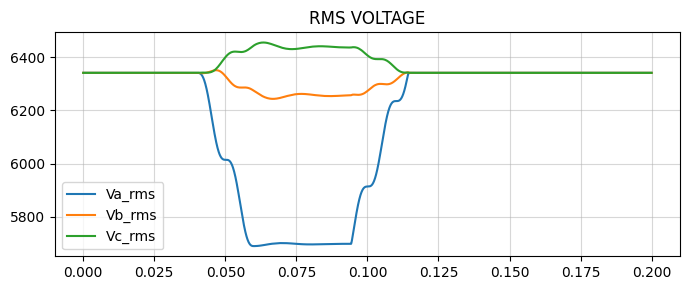

In [16]:
# RMS VOLTAGE VISUALIZE

fig,axs = plt.subplots(figsize=[7,3])
axs = axs
axs.set_title("RMS VOLTAGE")
axs.plot(df["Time"],df["Va_rms"],label = "Va_rms")
axs.plot(df["Time"],df["Vb_rms"],label = "Vb_rms")
axs.plot(df["Time"],df["Vc_rms"],label = "Vc_rms")
axs.grid(True,alpha = 0.5)
plt.tight_layout()
plt.legend()

In [17]:
# Seperating DataFrame for LG Fault

df_LG = pd.DataFrame()
df_LG = df.copy()

---
### MODEL TRAINING :

In [18]:
# Data Splitting :

features = ["Va_rms","Vb_rms","Vc_rms",
            "Ia_rms","Ib_rms","Ic_rms",
            "In_rms"]

x = df[features]
y = df["Fault_Type"]

In [19]:
# Training Function :

from sklearn.model_selection import cross_val_score,train_test_split
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay

def training_function(model,x,y):
    x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42)
    model_name = model.fit(x_train,y_train)
    prediction_value = model.predict(x_test)
    cv_score =  cross_val_score(model,x_train,y_train,
                scoring = "neg_mean_squared_error",cv = 5)
    cv_score =  np.abs(np.mean(cv_score))

    print("--- MODEL REPORT ---")
    print("MODEL TYPE :",model)
    print("CV SCORE :",cv_score)

    print("\n--- CLASSIFICATION REPORT ---")
    print(confusion_matrix(y_test, prediction_value))
    print(classification_report(y_test, prediction_value))

    fig, axs = plt.subplots(figsize=(10, 4))
    cm = confusion_matrix(y_test, prediction_value)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "LG"])
    disp.plot(cmap='Blues', ax=axs)
    plt.title("Confusion Matrix: Reality vs Prediction")
    plt.tight_layout()


    fig,axs = plt.subplots(figsize = [10,3])
    coeff = pd.Series(model.feature_importances_,x.columns).sort_values(ascending = False)
    coeff.plot(kind = "bar",title = "FEATURE IMPORTANCES",ax = axs)
    axs.grid(True,alpha = 0.5)
    plt.xticks(rotation = 45)


    plt.tight_layout()
    plt.show()


    return model_name   

--- MODEL REPORT ---
MODEL TYPE : RandomForestClassifier()
CV SCORE : 0.0006666666666666668

--- CLASSIFICATION REPORT ---
[[667   0]
 [  1 333]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       667
           1       1.00      1.00      1.00       334

    accuracy                           1.00      1001
   macro avg       1.00      1.00      1.00      1001
weighted avg       1.00      1.00      1.00      1001



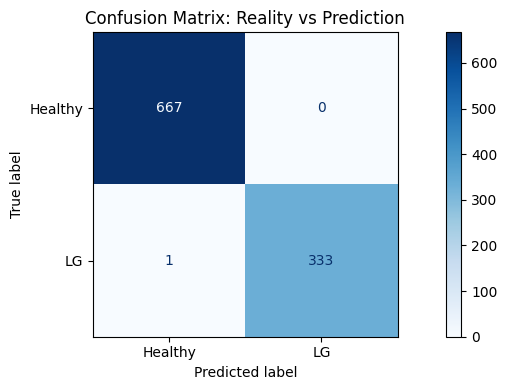

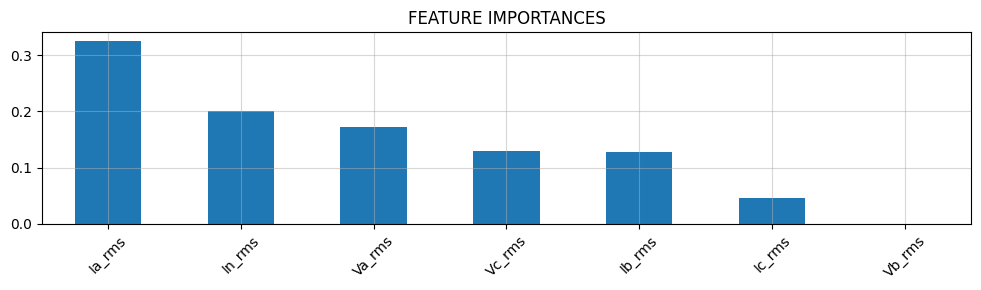

In [20]:
# Using Random Forest Model

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
LG_test_Model = training_function(model,x,y)

- The RMS data we have provided is very clear and clean due to which our A.I is making no mistakes during its prediction as we can observe that Flase Postive and Negtaive of our confusion matrix is 0. 

- Now to make A.I more robust, lets add some noise to our features and also make the feautres more harder and see what observations our A.I will obtain 

In [21]:
# Adding Noise Function :

np.random.seed(42)
def add_noise(series,percentage = 0.05):
    noise = np.random.normal(0,series.mean()*percentage,size = len(series))
    return series + noise

In [22]:
# Applying Noise to our features

features_to_noise = ["Va_rms","Vb_rms","Vc_rms",
                    "Ia_rms","Ib_rms","Ic_rms",
                    "In_rms"]

for feature in features_to_noise :
    df[feature] = add_noise(df[feature])

df.head()

,Time,Va,Vb,Vc,Ia,Ib,Ic,In,Va_rms,Vb_rms,Vc_rms,Ia_rms,Ib_rms,Ic_rms,In_rms,Fault_Type,Fault_Name
0,0.00000,-45.272684,-7744.036370,7789.309054,-9.431133,-58.984694,68.415827,0.0,6494.768722,6331.682531,6286.657232,51.687730,53.384401,50.552249,18.227916,0,Healthy
1,0.00005,95.598243,-7814.129517,7718.531274,-8.274637,-59.683372,67.958009,0.0,6298.890750,6347.235616,6569.117461,52.722882,57.462679,46.677846,8.511828,0,Healthy
2,0.00010,236.446869,-7882.295290,7645.848421,-7.116097,-60.367326,67.483423,0.0,6541.341258,6490.888403,6748.419904,55.682354,51.099098,56.926923,10.791797,0,Healthy
3,0.00015,377.235640,-7948.515472,7571.279832,-5.955796,-61.036388,66.992184,0.0,6811.366297,5909.630489,6523.189157,63.413241,54.661089,51.769777,14.304461,0,Healthy
4,0.00020,517.932637,-8012.775137,7494.842500,-4.794019,-61.690393,66.484412,0.0,6269.310916,6528.787135,6373.931775,51.800159,51.530147,58.679194,-3.840663,0,Healthy


--- MODEL REPORT ---
MODEL TYPE : RandomForestClassifier()
CV SCORE : 0.001

--- CLASSIFICATION REPORT ---
[[667   0]
 [  3 331]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       667
           1       1.00      0.99      1.00       334

    accuracy                           1.00      1001
   macro avg       1.00      1.00      1.00      1001
weighted avg       1.00      1.00      1.00      1001



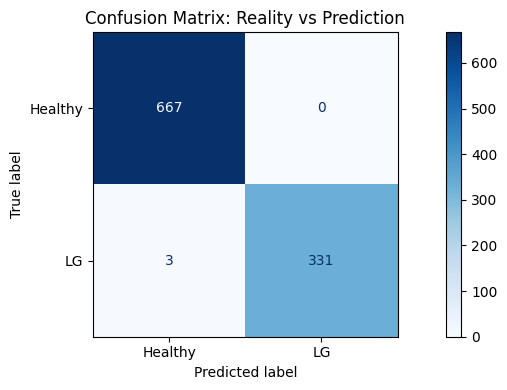

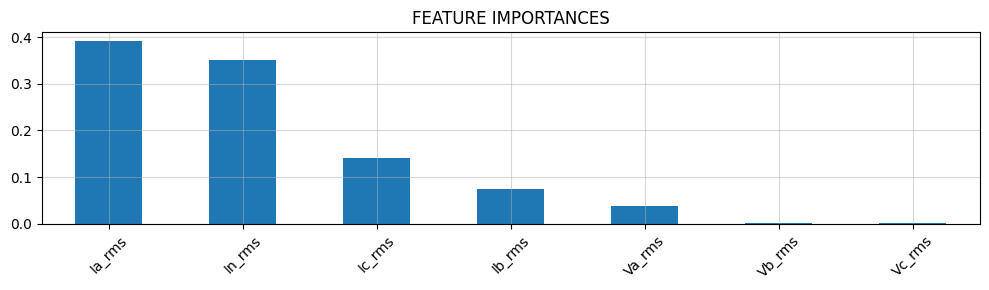

In [23]:
# Visualizing with noisy Data :

noisy_model = training_function(model = RandomForestClassifier(),
                    x = df[features_to_noise],
                    y = df["Fault_Type"])

- From the confusion matrix it is very sure that our A.I needs an improvement because when the scenario is faulty our A.I has given healthy logic twice in simulation, i.e. False Negative has existed.

- Better to have falsly trigger a safety system rather than staying quiet in the time of fault. If the A.I doesnt detect fault then this becomes very risky for the equipements as well as the materials associated with the grid, so we must solve this problem.

- We have used a standard model where if the predictio value crosses 50% then only it will predict an error, but due to addition of noise, some boundary values causes prediction to around lets say 48%, this causes A.I to not predict fault even at faulty case which is very deadly. 

- So we will make a new function such that even if the probablity of fault is around 10%, then it will classify it as fault, this makes sure our False Negative { Deadly One } becomes zero.

In [24]:
# Safer Training Function :

def safer_training_function(model,x,y):
    x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42)
    model_name = model.fit(x_train,y_train)
    probablities = model.predict_proba(x_test)[:,1] # Probablity of LG
    prediction_value = ( probablities > 0.1 ).astype(int)
    cv_score =  cross_val_score(model,x_train,y_train,
                scoring = "neg_mean_squared_error",cv = 5)
    cv_score =  np.abs(np.mean(cv_score))

    print("--- MODEL REPORT ---")
    print("MODEL TYPE :",model)
    print("CV SCORE :",cv_score)

    print("\n--- CLASSIFICATION REPORT ---")
    print(confusion_matrix(y_test, prediction_value))
    print(classification_report(y_test, prediction_value))

    fig, axs = plt.subplots(figsize=(10, 4))
    cm = confusion_matrix(y_test, prediction_value)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "LG"])
    disp.plot(cmap='Blues', ax=axs)
    plt.title("Confusion Matrix: Reality vs Prediction")
    plt.tight_layout()


    fig,axs = plt.subplots(figsize = [10,3])
    coeff = pd.Series(model.feature_importances_,x.columns).sort_values(ascending = False)
    coeff.plot(kind = "bar",title = "FEATURE IMPORTANCES",ax = axs)
    axs.grid(True,alpha = 0.5)
    plt.xticks(rotation = 45)

    plt.tight_layout()
    plt.show()

    return model_name   

--- MODEL REPORT ---
MODEL TYPE : RandomForestClassifier()
CV SCORE : 0.0016666666666666666

--- CLASSIFICATION REPORT ---
[[664   3]
 [  0 334]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       667
           1       0.99      1.00      1.00       334

    accuracy                           1.00      1001
   macro avg       1.00      1.00      1.00      1001
weighted avg       1.00      1.00      1.00      1001



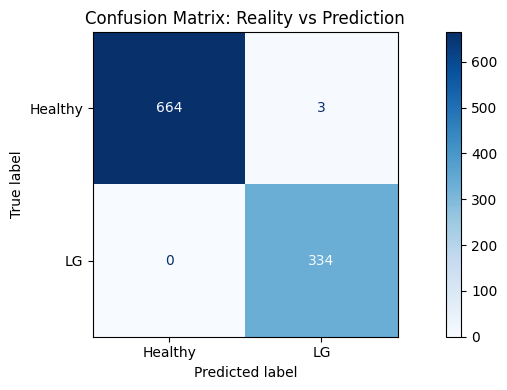

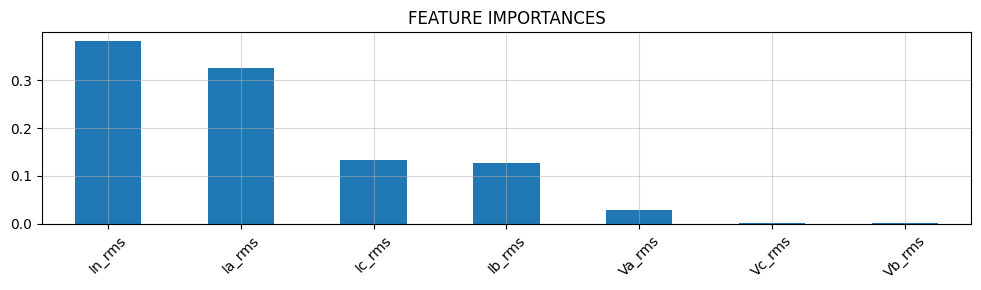

In [25]:
# Testing the safer training function :

model_safe = safer_training_function(model = RandomForestClassifier(),
                    x = df[features_to_noise],
                    y = df["Fault_Type"])

- As we can see that our False Negative criteria has been removed with sucess. This ensures that our A.I is more Robust and safer to use. It is better to have 10 False Positive { Detect False Fault in healthy scene } rather than to have 1 False Negative { Not Detect Fault in case of actual Fault }


---
- Here we have made data for the LG fault and then trained our model as per the LG fault detection. Now we must move towards LL fault detection

- The Physics for LG fault and LL fault is different as for LG fault, the In current and Phase current both spikes very high but for LL fault, currents of two phases will spike but that of the neutral current remains nearly zero.

- Now lets train our model for the LL fault

### LL FAULT DETECTION :

In [26]:
# Making DataFrame for LL fault

data_LL = loadmat("simulation_data_LL.mat")
Vabc = data_LL["Vabc"]
Iabc = data_LL["Iabc"]
t = data_LL["t"].squeeze()

df_v = pd.DataFrame()
df_v = pd.DataFrame(Vabc)
df_v.columns = ["Va","Vb","Vc"]

df_c = pd.DataFrame()
df_c = pd.DataFrame(Iabc)
df_c.columns = ["Ia","Ib","Ic"]

df_t = pd.DataFrame()
df_t["Time"] = pd.DataFrame(t) 

df_LL = pd.concat([df_t,df_v,df_c],axis = 1)

df_LL.head()

,Time,Va,Vb,Vc,Ia,Ib,Ic
0,0.00000,-45.272684,-7744.036370,7789.309054,-9.431133,-58.984694,68.415827
1,0.00005,95.598243,-7814.129517,7718.531274,-8.274637,-59.683372,67.958009
2,0.00010,236.446869,-7882.295290,7645.848421,-7.116097,-60.367326,67.483423
3,0.00015,377.235640,-7948.515472,7571.279832,-5.955796,-61.036388,66.992184
4,0.00020,517.932637,-8012.775137,7494.842500,-4.794019,-61.690393,66.484412


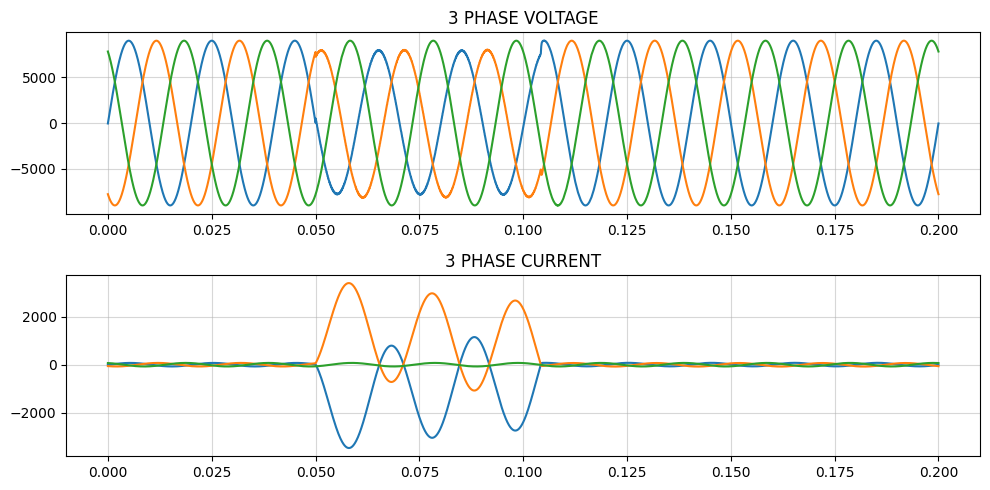

In [27]:
# Basic Visualization of the data gathered

fig,axs = plt.subplots(ncols = 1,nrows = 2,figsize =[10,5])
axs = axs.flatten()
axs[0].plot(t,Vabc)
axs[0].set_title("3 PHASE VOLTAGE")
axs[0].grid(True,alpha = 0.5)

axs[1].plot(t,Iabc)
axs[1].set_title("3 PHASE CURRENT")
axs[1].grid(True,alpha = 0.5)

plt.tight_layout()

In [28]:
# Performing Feature Engineering

df_LL["In"] = df_LL["Ia"] + df_LL["Ib"] + df_LL["Ic"]
df_LL.head()

,Time,Va,Vb,Vc,Ia,Ib,Ic,In
0,0.00000,-45.272684,-7744.036370,7789.309054,-9.431133,-58.984694,68.415827,-2.842171e-14
1,0.00005,95.598243,-7814.129517,7718.531274,-8.274637,-59.683372,67.958009,-1.421085e-14
2,0.00010,236.446869,-7882.295290,7645.848421,-7.116097,-60.367326,67.483423,-2.842171e-14
3,0.00015,377.235640,-7948.515472,7571.279832,-5.955796,-61.036388,66.992184,-5.684342e-14
4,0.00020,517.932637,-8012.775137,7494.842500,-4.794019,-61.690393,66.484412,-5.684342e-14


In [29]:
# Adding RMS Voltages and Currents 

phases = ["Va","Vb","Vc","Ia","Ib","Ic"]
rms_window = int((1/(5e-05))/50) # Roughly 400
for phase in phases:
    df_LL[f"{phase}_rms"] = np.sqrt((df_LL[phase]**2).rolling(window = 400,center = True).mean())

df_LL["In_rms"] = np.sqrt((df_LL["In"]**2).rolling(window = 400,center = True).mean())
df_LL = df_LL.bfill().ffill() # Rolling creates NAN values for first few samples as not enough samples

df_LL.head()

,Time,Va,Vb,Vc,Ia,Ib,Ic,In,Va_rms,Vb_rms,Vc_rms,Ia_rms,Ib_rms,Ic_rms,In_rms
0,0.00000,-45.272684,-7744.036370,7789.309054,-9.431133,-58.984694,68.415827,-2.842171e-14,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,1.161902e-12
1,0.00005,95.598243,-7814.129517,7718.531274,-8.274637,-59.683372,67.958009,-1.421085e-14,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,1.161902e-12
2,0.00010,236.446869,-7882.295290,7645.848421,-7.116097,-60.367326,67.483423,-2.842171e-14,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,1.161902e-12
3,0.00015,377.235640,-7948.515472,7571.279832,-5.955796,-61.036388,66.992184,-5.684342e-14,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,1.161902e-12
4,0.00020,517.932637,-8012.775137,7494.842500,-4.794019,-61.690393,66.484412,-5.684342e-14,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,1.161902e-12


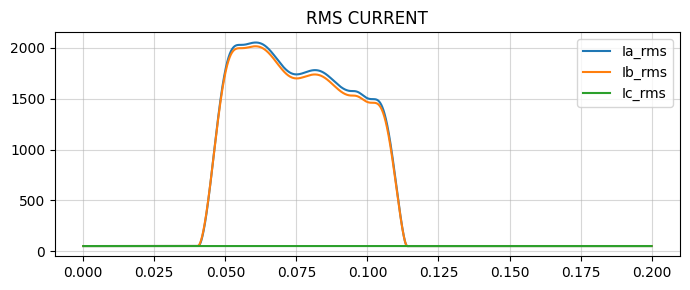

In [30]:
# RMS CURRENT VISUALIZATION 

fig,axs = plt.subplots(figsize=[7,3])
axs = axs
axs.set_title("RMS CURRENT")
axs.plot(df_LL["Time"],df_LL["Ia_rms"],label = "Ia_rms")
axs.plot(df_LL["Time"],df_LL["Ib_rms"],label = "Ib_rms")
axs.plot(df_LL["Time"],df_LL["Ic_rms"],label = "Ic_rms")
axs.grid(True,alpha = 0.5)
plt.tight_layout()
plt.legend()

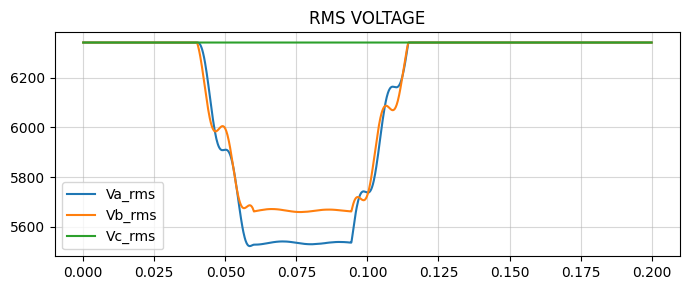

In [31]:
# RMS VOLTAGE VISUALIZATION 

fig,axs = plt.subplots(figsize=[7,3])
axs = axs
axs.set_title("RMS VOLTAGE")
axs.plot(df_LL["Time"],df_LL["Va_rms"],label = "Va_rms")
axs.plot(df_LL["Time"],df_LL["Vb_rms"],label = "Vb_rms")
axs.plot(df_LL["Time"],df_LL["Vc_rms"],label = "Vc_rms")
axs.grid(True,alpha = 0.5)
plt.tight_layout()
plt.legend()

- LG Fault and LL fault are distinguished in different manners because they have differnt nature of occurance as we can see below in the figure.

- In LL fault the In current remains almost zero but for that of LG fault In spikes up which acts as a most significant feature for the model training.

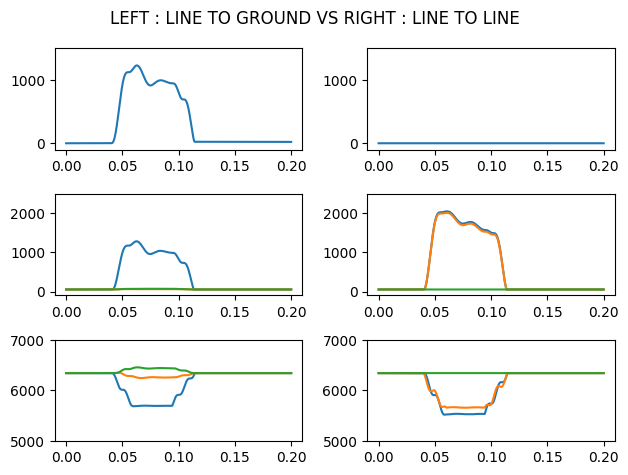

In [32]:
# FEATURE COMPARISON FOR LG AND LL FAULT DETECTION 

fig,axs = plt.subplots(ncols = 2,nrows = 3)
axs = axs.flatten()
fig.suptitle("LEFT : LINE TO GROUND VS RIGHT : LINE TO LINE")

axs[0].plot(df_LG["Time"],df_LG["In_rms"],label = "In_rms LG")
axs[0].set_ylim([-100,1500])
axs[1].plot(df_LL["Time"],df_LL["In_rms"],label = "In_rms LL")
axs[1].set_ylim([-100,1500])

axs[2].plot(df_LG["Time"],df_LG["Ia_rms"],label = "Ia_rms")
axs[2].plot(df_LG["Time"],df_LG["Ib_rms"],label = "Ib_rms")
axs[2].plot(df_LG["Time"],df_LG["Ic_rms"],label = "Ic_rms")
axs[2].set_ylim([-100,2500])



axs[3].plot(df_LL["Time"],df_LL["Ia_rms"],label = "Ia_rms")
axs[3].plot(df_LL["Time"],df_LL["Ib_rms"],label = "Ib_rms")
axs[3].plot(df_LL["Time"],df_LL["Ic_rms"],label = "Ic_rms")
axs[3].set_ylim([-100,2500])


axs[4].plot(df_LG["Time"],df_LG["Va_rms"],label = "Va_rms")
axs[4].plot(df_LG["Time"],df_LG["Vb_rms"],label = "Vb_rms")
axs[4].plot(df_LG["Time"],df_LG["Vc_rms"],label = "Vc_rms")
axs[4].set_ylim([5000,7000])



axs[5].plot(df_LL["Time"],df_LL["Va_rms"],label = "Va_rms")
axs[5].plot(df_LL["Time"],df_LL["Vb_rms"],label = "Vb_rms")
axs[5].plot(df_LL["Time"],df_LL["Vc_rms"],label = "Vc_rms")
axs[5].set_ylim([5000,7000])

plt.tight_layout()


In [33]:
# Fault Detection 

threshold_rms = 120

max_current_LG = df_LG[["Ia_rms","Ib_rms","Ic_rms"]].max(axis=1)
df_LG["Fault_Type"] = (max_current_LG > threshold_rms).astype(int)*1

max_current_LL = df_LL[["Ia_rms","Ib_rms","Ic_rms"]].max(axis=1)
df_LL["Fault_Type"] = (max_current_LL > threshold_rms).astype(int)*2


In [34]:
# Master DataFrame Making

df = pd.DataFrame()
df = pd.concat([df_LG,df_LL],axis = 0)

fault_map = {0:"Healthy",1:"LG",2:"LL"}
df["Fault_Name"] = df["Fault_Type"].map(fault_map)

df.head()


,Time,Va,Vb,Vc,Ia,Ib,Ic,In,Va_rms,Vb_rms,Vc_rms,Ia_rms,Ib_rms,Ic_rms,In_rms,Fault_Type,Fault_Name
0,0.00000,-45.272684,-7744.036370,7789.309054,-9.431133,-58.984694,68.415827,0.0,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,0.0,0,Healthy
1,0.00005,95.598243,-7814.129517,7718.531274,-8.274637,-59.683372,67.958009,0.0,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,0.0,0,Healthy
2,0.00010,236.446869,-7882.295290,7645.848421,-7.116097,-60.367326,67.483423,0.0,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,0.0,0,Healthy
3,0.00015,377.235640,-7948.515472,7571.279832,-5.955796,-61.036388,66.992184,0.0,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,0.0,0,Healthy
4,0.00020,517.932637,-8012.775137,7494.842500,-4.794019,-61.690393,66.484412,0.0,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,0.0,0,Healthy


---
### MODEL TRAINING : LG + LL + Healthy

In [35]:
# Data Splitting

features = ["Va_rms","Vb_rms","Vc_rms",
            "Ia_rms","Ib_rms","Ic_rms",
            "In_rms"]

x = df[features]
y = df["Fault_Type"]

In [36]:
# Training Function 

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report
from sklearn.model_selection import train_test_split,cross_val_score

def multiclass_training_function(model,x,y):
    threshold_probablity = 0.1 # 10% fault chance then declare as fault
    x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42)
    model_name = model.fit(x_train,y_train)
    probabilities = model.predict_proba(x_test)
    probablity_of_any_fault = probabilities[:,1] + probabilities[:,2]
    model_prediction_value = model.predict(x_test)

    risky_case = ((probablity_of_any_fault > threshold_probablity)
                        & (model_prediction_value == 0)) # EXPLANATION BELOW
    
    model_prediction_value[risky_case] = (np.argmax(probabilities[risky_case, 1:], 
                                            axis=1) + 1) 
    
    cv_score =  cross_val_score(model,x_train,y_train,
                scoring = "neg_mean_squared_error",cv = 5)
    cv_score =  np.abs(np.mean(cv_score))

    

    print("--- MODEL REPORT ---")
    print("MODEL TYPE :",model)
    print("CV SCORE :",cv_score)

    print("\nCLASSIFICATION REPORT :")
    report = classification_report(y_test,model_prediction_value,
                target_names=["Healthy","LG","LL"])
    print(report)


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    cm = confusion_matrix(y_test, model_prediction_value)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "LG", "LL"])
    disp.plot(cmap='Blues', ax=ax1, colorbar=False)
    ax1.set_title("Confusion Matrix (Reality vs Prediction)")
    
    importances = pd.Series(model.feature_importances_, index=x.columns).sort_values(ascending=False)
    importances.plot(kind='bar', ax=ax2, color='teal')
    ax2.set_title("Feature Importance ")
    ax2.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    return model_name


Explanation :

- The above risky_case and masking of the code is done as a safety measure. Example : If the probablity of any kind of fault is around 10% then if we compare with standard value i.e. model predicted value it will say healthy as 50% probablity is not reached.

- But, it is better to have a reliable system than a secure system, so even 10% chance is better to consider as it can be detrimental in the long run, system is more better if it gives 10 false alarms for false faults then no alarm for the actual fault.

--- MODEL REPORT ---
MODEL TYPE : RandomForestClassifier()
CV SCORE : 0.0008333333333333333

CLASSIFICATION REPORT :
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00      1272
          LG       1.00      1.00      1.00       355
          LL       1.00      1.00      1.00       374

    accuracy                           1.00      2001
   macro avg       1.00      1.00      1.00      2001
weighted avg       1.00      1.00      1.00      2001



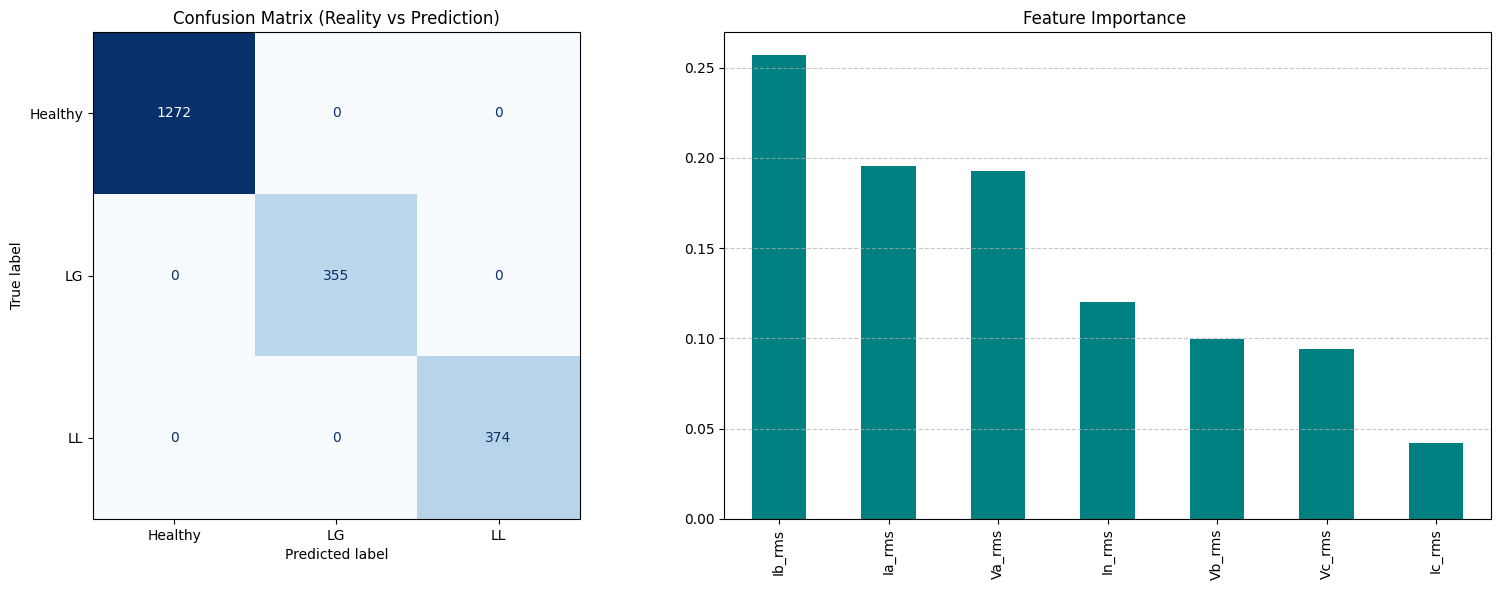

In [37]:
features = ["Va_rms","Vb_rms","Vc_rms",
            "Ia_rms","Ib_rms","Ic_rms",
            "In_rms"]

model_LL_LG = multiclass_training_function(model = RandomForestClassifier(),
                        x = df[features],
                        y = df["Fault_Type"])

- Repeating the same process, our data is too much ideal for the model to train it and become robust

- Adding noise to our data so that our model becomes much more robust and doesnt overfit in the testing sesson

- Point to be noted is that, there must never be the condition of False Negative because the system must not predict healthy if actual fault has occured. Other than that, False positive error can be taken into consideration.

--- MODEL REPORT ---
MODEL TYPE : RandomForestClassifier()
CV SCORE : 0.004832639467110741

CLASSIFICATION REPORT :
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00      1272
          LG       1.00      1.00      1.00       355
          LL       1.00      1.00      1.00       374

    accuracy                           1.00      2001
   macro avg       1.00      1.00      1.00      2001
weighted avg       1.00      1.00      1.00      2001



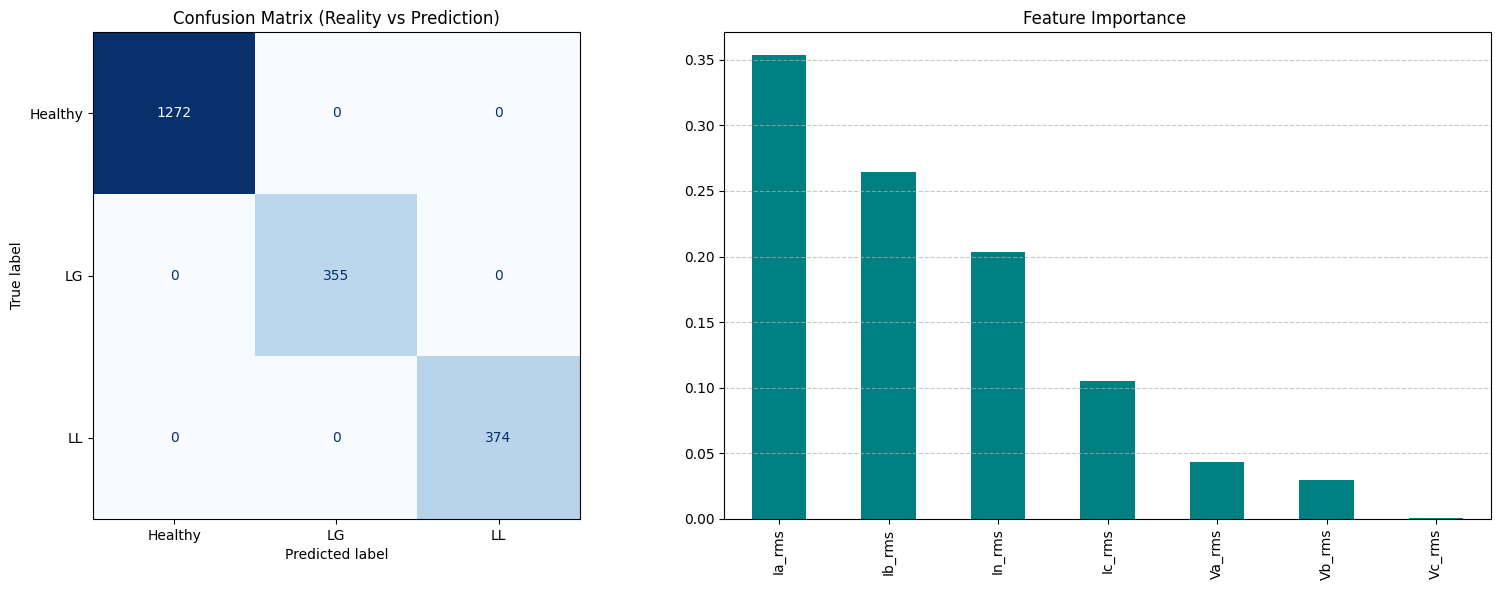

In [38]:
# TRAINING WITH NOISE 

features_to_noise = ["Va_rms","Vb_rms","Vc_rms",
                    "Ia_rms","Ib_rms","Ic_rms",
                    "In_rms"]

for feature in features_to_noise :
    df[feature] = add_noise(df[feature])

Final_Model = multiclass_training_function(model = RandomForestClassifier(),
                        x = df[features_to_noise],
                        y = df["Fault_Type"])

---
### MODEL ACCURACY TESTING :

- Our model is trained using the data we have provided in the simulink. Lets create a new data from simulink

- This data is not seen by our model so we will test the accuracy of our model and see how much our model has learnt up till this point. 

- This test will also ensure that our model isnt prone to over fitting as we have seen that cross validation score of our model is very small. Lets see how this goes and turns out then.

In [39]:
# OBSERVING OUR ORIGINAL DATAFRAME

df.head()

,Time,Va,Vb,Vc,Ia,Ib,Ic,In,Va_rms,Vb_rms,Vc_rms,Ia_rms,Ib_rms,Ic_rms,In_rms,Fault_Type,Fault_Name
0,0.00000,-45.272684,-7744.036370,7789.309054,-9.431133,-58.984694,68.415827,0.0,6195.681328,5969.277574,6314.442570,52.980936,35.199753,51.409747,-8.818615,0,Healthy
1,0.00005,95.598243,-7814.129517,7718.531274,-8.274637,-59.683372,67.958009,0.0,6787.652747,6298.078285,6340.043879,34.913981,43.604776,53.077461,10.922643,0,Healthy
2,0.00010,236.446869,-7882.295290,7645.848421,-7.116097,-60.367326,67.483423,0.0,6270.661347,6237.172454,6278.720963,39.338754,26.099140,53.777553,12.418173,0,Healthy
3,0.00015,377.235640,-7948.515472,7571.279832,-5.955796,-61.036388,66.992184,0.0,6215.404806,6413.495189,6662.820768,48.086021,78.414350,50.722949,3.619012,0,Healthy
4,0.00020,517.932637,-8012.775137,7494.842500,-4.794019,-61.690393,66.484412,0.0,6230.213676,6630.333315,6494.798807,67.683037,52.367189,46.668398,6.438083,0,Healthy


In [40]:
# MAKING TEST DATAFRAME 

test_data = loadmat("simulation_data_testing.mat") # It is Line to Line Fault Demo
Vabc_test = test_data["Vabc"]
Iabc_test = test_data["Iabc"]
t_test = test_data["t"]

df_test = pd.DataFrame()
df_test["Time"] = pd.DataFrame(t_test)
df_test[["Va","Vb","Vc"]] = pd.DataFrame(Vabc_test)
df_test[["Ia","Ib","Ic"]] = pd.DataFrame(Iabc_test)

df_test["In"] = df_test["Ia"] + df_test["Ib"] + df_test["Ic"]

phases = ["Va","Vb","Vc","Ia","Ib","Ic"]
for phase in phases:
    df_test[f"{phase}_rms"] = np.sqrt((df_test[phase]**2).rolling(window = 400,
                                center = True).mean())
df_test["In_rms"] = np.sqrt((df_test["In"]**2).rolling(window = 400,
                                center = True).mean())
df_test = df_test.bfill().ffill()

df_test.head()

,Time,Va,Vb,Vc,Ia,Ib,Ic,In,Va_rms,Vb_rms,Vc_rms,Ia_rms,Ib_rms,Ic_rms,In_rms
0,0.00000,-45.272684,-7744.036370,7789.309054,-9.431133,-58.984694,68.415827,-2.842171e-14,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,1.161902e-12
1,0.00005,95.598243,-7814.129517,7718.531274,-8.274637,-59.683372,67.958009,-1.421085e-14,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,1.161902e-12
2,0.00010,236.446869,-7882.295290,7645.848421,-7.116097,-60.367326,67.483423,-2.842171e-14,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,1.161902e-12
3,0.00015,377.235640,-7948.515472,7571.279832,-5.955796,-61.036388,66.992184,-5.684342e-14,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,1.161902e-12
4,0.00020,517.932637,-8012.775137,7494.842500,-4.794019,-61.690393,66.484412,-5.684342e-14,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,1.161902e-12


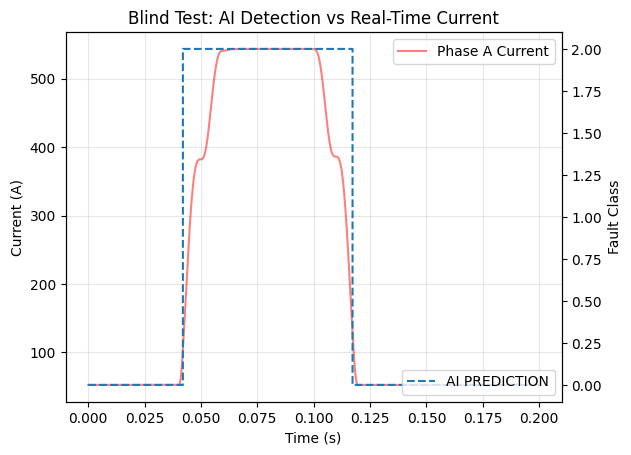

In [41]:
# TESTING PROCESS :

features = ["Va_rms","Vb_rms","Vc_rms",
            "Ia_rms","Ib_rms","Ic_rms",
            "In_rms"]

test_probs = Final_Model.predict_proba(df_test[features])

prob_any_fault = test_probs[:,1] + test_probs[:,2]
test_preds = Final_Model.predict(df_test[features])

test_preds[prob_any_fault > 0.1] = (np.argmax(test_probs[prob_any_fault > 0.1, 1:], 
                                    axis=1) + 1) # VERY IMP LOGIC
test_preds[prob_any_fault <= 0.1] = 0

df_test["AI_DECISION"] = test_preds

fig, ax = plt.subplots()
ax.plot(df_test["Time"], df_test["Ia_rms"], 
        label="Phase A Current", color='red', alpha=0.5)

ax2 = ax.twinx() 
ax2.step(df_test["Time"], df_test["AI_DECISION"],
         label="AI PREDICTION", ls = "--", where='post')

ax.set_xlabel("Time (s)")
ax.set_ylabel("Current (A)")
ax2.set_ylabel("Fault Class")

plt.title("Blind Test: AI Detection vs Real-Time Current")
ax.legend(loc='upper right')
ax2.legend(loc='lower right')
ax.grid(True,alpha = 0.3)
plt.show()


IMPORTANT CONCLUSIONS :

-  During plotting ax.step() we have used where = post, which allows us to see the delay of the AI in making the prediction. Here we can see in the graph that as soon as the current rises, the prediction is made by our AI, this prediction might be 1 for LG or 2 or LL, for this case it is 2 as we can see in the 2nd axis. This shows that our AI has very less delay around few micro seconds.

---
### LLL FAULT :

- Now that we have covered about LG and LL faults, its time to move towards the final type of fault in our AI detection system. We have to take into account for the LLL fault.

- In LLL type of fault, all the 3 phases will get short circuited at the same time, during this period the rms value of neutral current remains nearly zero as the system is still in balanced condition.

- But the factor that causes difference is that the rms value of the phase current will spike very high during the condition of fault, thus we use this for our AI model to detect the LLL type of fault.




In [42]:
# Loading Data

data_LLL = loadmat("simulation_data_LLL.mat")
Vabc = data_LLL["Vabc"]
Iabc = data_LLL["Iabc"]
t = data_LLL["t"].squeeze()

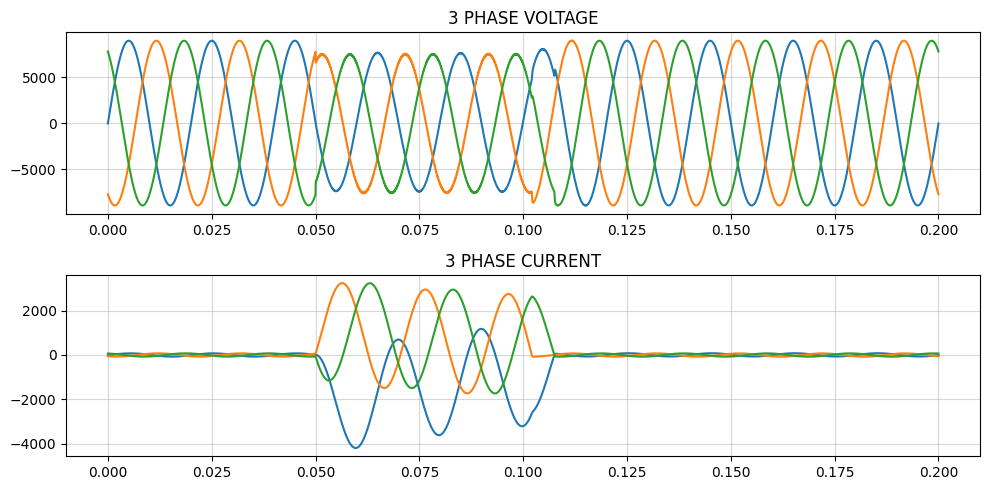

In [43]:
# SIMPLE VISUALIZATION

fig,axs = plt.subplots(ncols = 1,nrows = 2,figsize =[10,5])
axs = axs.flatten()
axs[0].plot(t,Vabc)
axs[0].set_title("3 PHASE VOLTAGE")
axs[0].grid(True,alpha = 0.5)

axs[1].plot(t,Iabc)
axs[1].set_title("3 PHASE CURRENT")
axs[1].grid(True,alpha = 0.5)

plt.tight_layout()

In [44]:
# Construction of DataFrame

df_LLL = pd.DataFrame(t,columns = ["Time"])
df_LLL[["Va","Vb","Vc"]] = pd.DataFrame(Vabc)
df_LLL[["Ia","Ib","Ic"]] = pd.DataFrame(Iabc)
df_LLL["In"] = df_LLL["Ia"] + df_LLL["Ib"] + df_LLL["Ic"]

df_LLL.head()

,Time,Va,Vb,Vc,Ia,Ib,Ic,In
0,0.00000,-45.272684,-7744.036370,7789.309054,-9.431133,-58.984694,68.415827,-2.842171e-14
1,0.00005,95.598243,-7814.129517,7718.531274,-8.274637,-59.683372,67.958009,-1.421085e-14
2,0.00010,236.446869,-7882.295290,7645.848421,-7.116097,-60.367326,67.483423,-2.842171e-14
3,0.00015,377.235640,-7948.515472,7571.279832,-5.955796,-61.036388,66.992184,-5.684342e-14
4,0.00020,517.932637,-8012.775137,7494.842500,-4.794019,-61.690393,66.484412,-5.684342e-14


In [45]:
# ADDING RMS VALUES

phases = ["Va","Vb","Vc","Ia","Ib","Ic"]
rms_window = int((1/(5e-05))/50) # Roughly 400
for phase in phases:
    df_LLL[f"{phase}_rms"] = np.sqrt((df_LLL[phase]**2).rolling(window = 400,center = True).mean())

df_LLL["In_rms"] = np.sqrt((df_LLL["In"]**2).rolling(window = 400,center = True).mean())
df_LLL = df_LLL.bfill().ffill() # Rolling creates NAN values for first few samples as not enough samples

df_LLL.head()

,Time,Va,Vb,Vc,Ia,Ib,Ic,In,Va_rms,Vb_rms,Vc_rms,Ia_rms,Ib_rms,Ic_rms,In_rms
0,0.00000,-45.272684,-7744.036370,7789.309054,-9.431133,-58.984694,68.415827,-2.842171e-14,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,1.161902e-12
1,0.00005,95.598243,-7814.129517,7718.531274,-8.274637,-59.683372,67.958009,-1.421085e-14,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,1.161902e-12
2,0.00010,236.446869,-7882.295290,7645.848421,-7.116097,-60.367326,67.483423,-2.842171e-14,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,1.161902e-12
3,0.00015,377.235640,-7948.515472,7571.279832,-5.955796,-61.036388,66.992184,-5.684342e-14,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,1.161902e-12
4,0.00020,517.932637,-8012.775137,7494.842500,-4.794019,-61.690393,66.484412,-5.684342e-14,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,1.161902e-12


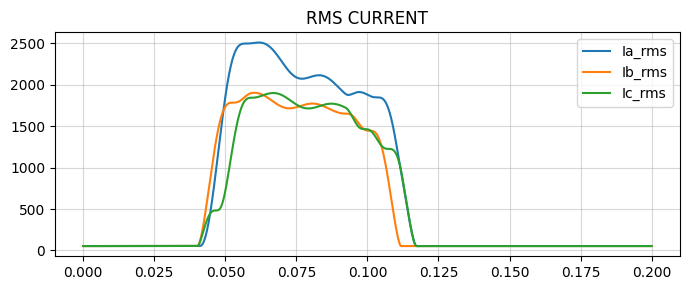

In [46]:
# RMS CURRENT VISUALIZATION 

fig,axs = plt.subplots(figsize=[7,3])
axs = axs
axs.set_title("RMS CURRENT")
axs.plot(df_LLL["Time"],df_LLL["Ia_rms"],label = "Ia_rms")
axs.plot(df_LLL["Time"],df_LLL["Ib_rms"],label = "Ib_rms")
axs.plot(df_LLL["Time"],df_LLL["Ic_rms"],label = "Ic_rms")
axs.grid(True,alpha = 0.5)
plt.tight_layout()
plt.legend()

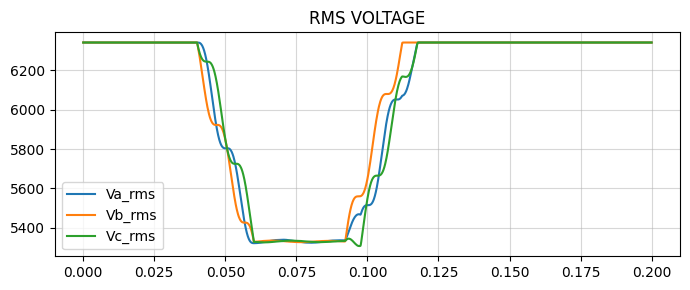

In [47]:
# RMS VOLTAGE VISUALIZATION 

fig,axs = plt.subplots(figsize=[7,3])
axs = axs
axs.set_title("RMS VOLTAGE")
axs.plot(df_LLL["Time"],df_LLL["Va_rms"],label = "Va_rms")
axs.plot(df_LLL["Time"],df_LLL["Vb_rms"],label = "Vb_rms")
axs.plot(df_LLL["Time"],df_LLL["Vc_rms"],label = "Vc_rms")
axs.grid(True,alpha = 0.5)
plt.tight_layout()
plt.legend()

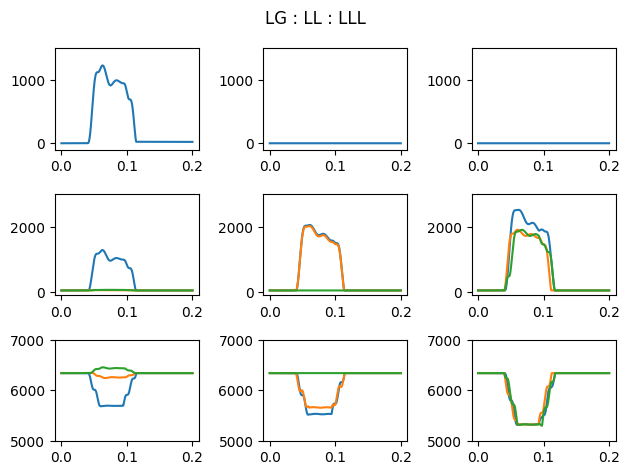

In [48]:
# FEATURE COMPARISION FOR ALL THE FAULTS

fig,axs = plt.subplots(ncols = 3,nrows = 3)
axs = axs.flatten()
fig.suptitle("LG : LL : LLL")

axs[0].plot(df_LG["Time"],df_LG["In_rms"],label = "In_rms LG")
axs[0].set_ylim([-100,1500])

axs[1].plot(df_LL["Time"],df_LLL["In_rms"],label = "In_rms LL")
axs[1].set_ylim([-100,1500])

axs[2].plot(df_LLL["Time"],df_LLL["In_rms"],label = "In_rms LLL")
axs[2].set_ylim([-100,1500])




axs[3].plot(df_LG["Time"],df_LG["Ia_rms"],label = "Ia_rms")
axs[3].plot(df_LG["Time"],df_LG["Ib_rms"],label = "Ib_rms")
axs[3].plot(df_LG["Time"],df_LG["Ic_rms"],label = "Ic_rms")
axs[3].set_ylim([-100,3000])

axs[4].plot(df_LL["Time"],df_LL["Ia_rms"],label = "Ia_rms")
axs[4].plot(df_LL["Time"],df_LL["Ib_rms"],label = "Ib_rms")
axs[4].plot(df_LL["Time"],df_LL["Ic_rms"],label = "Ic_rms")
axs[4].set_ylim([-100,3000])

axs[5].plot(df_LLL["Time"],df_LLL["Ia_rms"],label = "Ia_rms")
axs[5].plot(df_LLL["Time"],df_LLL["Ib_rms"],label = "Ib_rms")
axs[5].plot(df_LLL["Time"],df_LLL["Ic_rms"],label = "Ic_rms")
axs[5].set_ylim([-100,3000])




axs[6].plot(df_LG["Time"],df_LG["Va_rms"],label = "Va_rms")
axs[6].plot(df_LG["Time"],df_LG["Vb_rms"],label = "Vb_rms")
axs[6].plot(df_LG["Time"],df_LG["Vc_rms"],label = "Vc_rms")
axs[6].set_ylim([5000,7000])

axs[7].plot(df_LL["Time"],df_LL["Va_rms"],label = "Va_rms")
axs[7].plot(df_LL["Time"],df_LL["Vb_rms"],label = "Vb_rms")
axs[7].plot(df_LL["Time"],df_LL["Vc_rms"],label = "Vc_rms")
axs[7].set_ylim([5000,7000])

axs[8].plot(df_LLL["Time"],df_LLL["Va_rms"],label = "Va_rms")
axs[8].plot(df_LLL["Time"],df_LLL["Vb_rms"],label = "Vb_rms")
axs[8].plot(df_LLL["Time"],df_LLL["Vc_rms"],label = "Vc_rms")
axs[8].set_ylim([5000,7000])


plt.tight_layout()


In [49]:
# Fault Detection 

threshold_rms = 120

max_current_LG = df_LG[["Ia_rms","Ib_rms","Ic_rms"]].max(axis=1)
df_LG["Fault_Type"] = (max_current_LG > threshold_rms).astype(int)*1

max_current_LL = df_LL[["Ia_rms","Ib_rms","Ic_rms"]].max(axis=1)
df_LL["Fault_Type"] = (max_current_LL > threshold_rms).astype(int)*2

max_current_LLL = df_LLL[["Ia_rms","Ib_rms","Ic_rms"]].max(axis=1)
df_LLL["Fault_Type"] = (max_current_LLL > threshold_rms).astype(int)*3


In [50]:
# Master DataFrame Making

df = pd.DataFrame()
df = pd.concat([df_LG,df_LL,df_LLL],axis = 0)

fault_map = {0:"Healthy",1:"LG",2:"LL",3:"LLL"}
df["Fault_Name"] = df["Fault_Type"].map(fault_map)

df.head()

,Time,Va,Vb,Vc,Ia,Ib,Ic,In,Va_rms,Vb_rms,Vc_rms,Ia_rms,Ib_rms,Ic_rms,In_rms,Fault_Type,Fault_Name
0,0.00000,-45.272684,-7744.036370,7789.309054,-9.431133,-58.984694,68.415827,0.0,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,0.0,0,Healthy
1,0.00005,95.598243,-7814.129517,7718.531274,-8.274637,-59.683372,67.958009,0.0,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,0.0,0,Healthy
2,0.00010,236.446869,-7882.295290,7645.848421,-7.116097,-60.367326,67.483423,0.0,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,0.0,0,Healthy
3,0.00015,377.235640,-7948.515472,7571.279832,-5.955796,-61.036388,66.992184,0.0,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,0.0,0,Healthy
4,0.00020,517.932637,-8012.775137,7494.842500,-4.794019,-61.690393,66.484412,0.0,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,0.0,0,Healthy


--- 
### FINAL MODEL TRAINING

In [51]:
# Data Splitting

features = ["Va_rms","Vb_rms","Vc_rms",
            "Ia_rms","Ib_rms","Ic_rms",
            "In_rms"]

x = df[features]
y = df["Fault_Type"]

In [52]:
# MAKING TRAINING FUNCTION

def final_training_function(model,x,y):
    threshold_probablity = 0.1 # 10% fault chance then declare as fault
    x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42)
    model_name = model.fit(x_train,y_train)
    probabilities = model.predict_proba(x_test)
    probablity_of_any_fault = probabilities[:,1] + probabilities[:,2] + probabilities[:,3]
    model_prediction_value = model.predict(x_test)

    ### VERY VERY IMP LOGIC : MAIN THEME OF VoltFix AI ------------------

    risky_case = ((probablity_of_any_fault > threshold_probablity)
                        & (model_prediction_value == 0)) 
    
    model_prediction_value[risky_case] = (np.argmax(probabilities[risky_case, 1:], 
                                            axis=1) + 1) 
    
    ### ------------------------------------------------------------------
    
    cv_score =  cross_val_score(model,x_train,y_train,
                scoring = "neg_mean_squared_error",cv = 5)
    cv_score =  np.abs(np.mean(cv_score))

    

    print("--- MODEL REPORT ---")
    print("MODEL TYPE :",model)
    print("CV SCORE :",cv_score)

    print("\nCLASSIFICATION REPORT :")
    report = classification_report(y_test,model_prediction_value,
                target_names=["Healthy","LG","LL","LLL"])
    print(report)


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    cm = confusion_matrix(y_test, model_prediction_value)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                    display_labels=["Healthy", "LG", "LL","LLL"])
    disp.plot(cmap='Blues', ax=ax1, colorbar=False)
    ax1.set_title("Confusion Matrix (Reality vs Prediction)")
    
    importances = pd.Series(model.feature_importances_, 
                    index=x.columns).sort_values(ascending=False)
    importances.plot(kind='bar', ax=ax2, color='teal')
    ax2.set_title("Feature Importance ")
    ax2.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    return model_name


--- MODEL REPORT ---
MODEL TYPE : RandomForestClassifier()
CV SCORE : 0.0011105558640261584

CLASSIFICATION REPORT :
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00      1901
          LG       1.00      1.00      1.00       344
          LL       1.00      1.00      1.00       369
         LLL       1.00      1.00      1.00       387

    accuracy                           1.00      3001
   macro avg       1.00      1.00      1.00      3001
weighted avg       1.00      1.00      1.00      3001



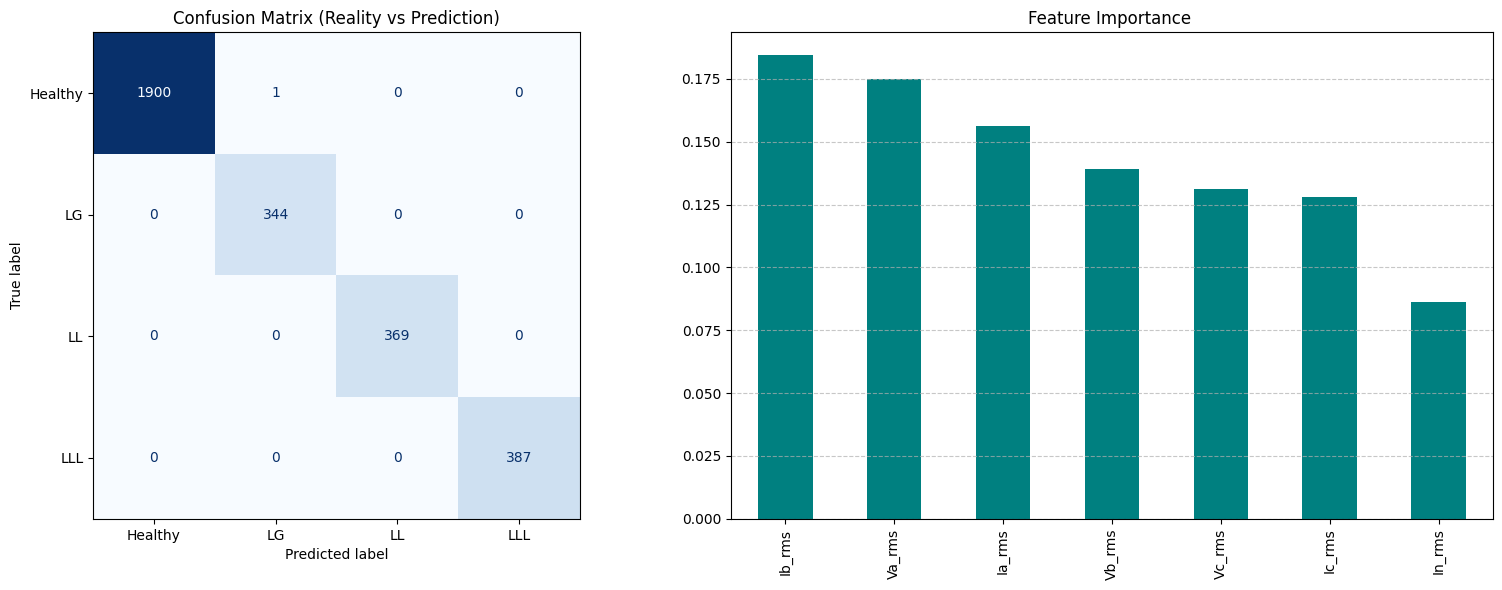

In [53]:
features = ["Va_rms","Vb_rms","Vc_rms",
            "Ia_rms","Ib_rms","Ic_rms",
            "In_rms"]

all_fault_model = final_training_function(model = RandomForestClassifier(),
                    x = df[features],
                    y = df["Fault_Type"])

--- 
REFINING THE TRAINING PROCESS BY ADDING NOISE :

- Again as the previous step continues, this data that we have provided from Simulink directly is very pure and ideal in nature, so we must add some amount of noise to this to showcase a real world type behavious

- After we add the noise to our data and then finally train the model, our final trained model will be ready

- After the model is ready, we must check for the Flase Negative Cases in our data, as this is very serious matter of concern for our system to work properly

--- MODEL REPORT ---
MODEL TYPE : RandomForestClassifier()
CV SCORE : 0.006554136590782899

CLASSIFICATION REPORT :
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00      1901
          LG       0.99      0.99      0.99       344
          LL       0.99      1.00      1.00       369
         LLL       1.00      1.00      1.00       387

    accuracy                           1.00      3001
   macro avg       1.00      1.00      1.00      3001
weighted avg       1.00      1.00      1.00      3001



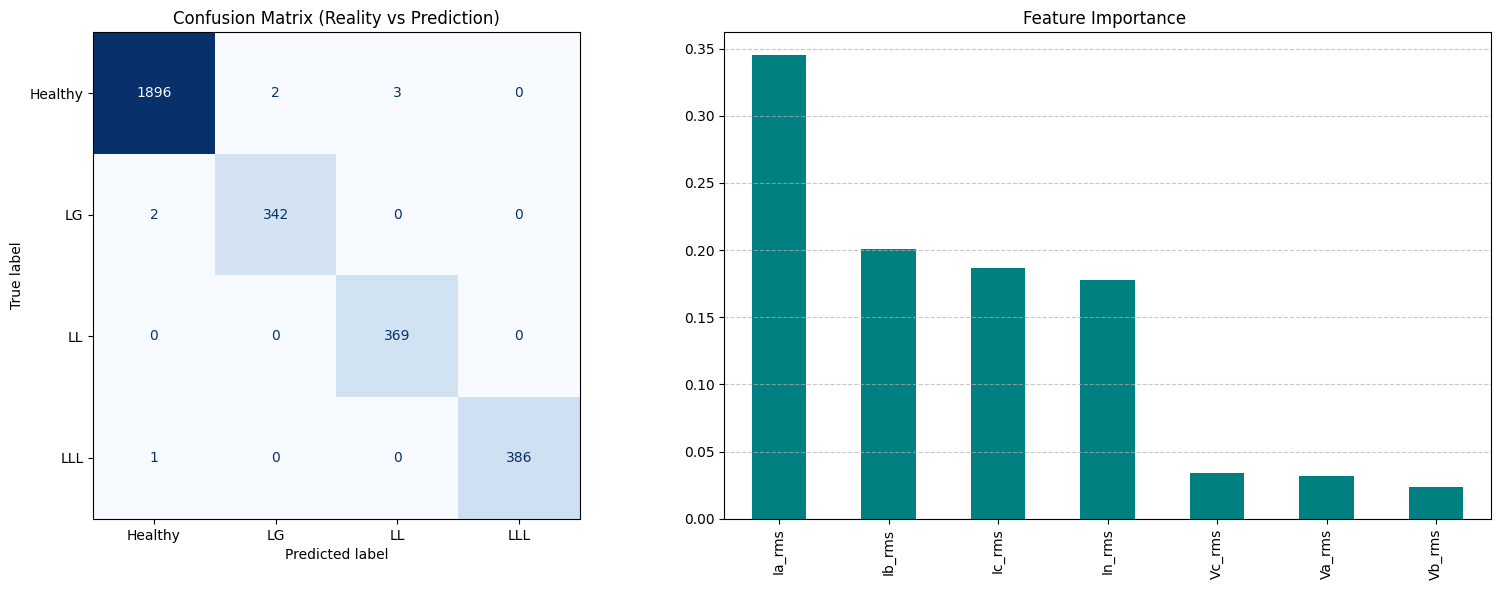

In [54]:
# TRAINING WITH NOISE 

features_to_noise = ["Va_rms","Vb_rms","Vc_rms",
                    "Ia_rms","Ib_rms","Ic_rms",
                    "In_rms"]

for feature in features_to_noise :
    df[feature] = add_noise(df[feature])

VoltFix_AI_Model = final_training_function(model = RandomForestClassifier(),
                        x = df[features_to_noise],
                        y = df["Fault_Type"])

---
### FINAL TESTING OF THE MODEL

- Here, We have successfully prepared our model that can detect all 3 types of faults in power system which is LL,LG and LLL type of fault. 

- Now to test the robustness of our model and to see the proper validity we will add around 20% noise to our data, simulating very noisy model and then we will predict the accuracy and see the model's accuracy in that condition.



In [56]:
# MAKING TEST DATAFRAME 

test_data = loadmat("simulation_data_final_test.mat") 
Vabc_test = test_data["Vabc"]
Iabc_test = test_data["Iabc"]
t_test = test_data["t"]

df_test = pd.DataFrame()
df_test["Time"] = pd.DataFrame(t_test)
df_test[["Va","Vb","Vc"]] = pd.DataFrame(Vabc_test)
df_test[["Ia","Ib","Ic"]] = pd.DataFrame(Iabc_test)

df_test["In"] = df_test["Ia"] + df_test["Ib"] + df_test["Ic"]

phases = ["Va","Vb","Vc","Ia","Ib","Ic"]
for phase in phases:
    df_test[f"{phase}_rms"] = np.sqrt((df_test[phase]**2).rolling(window = 400,
                                center = True).mean())
df_test["In_rms"] = np.sqrt((df_test["In"]**2).rolling(window = 400,
                                center = True).mean())
df_test = df_test.bfill().ffill()

df_test.head()

,Time,Va,Vb,Vc,Ia,Ib,Ic,In,Va_rms,Vb_rms,Vc_rms,Ia_rms,Ib_rms,Ic_rms,In_rms
0,0.00000,-45.272684,-7744.036370,7789.309054,-9.431133,-58.984694,68.415827,-2.842171e-14,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,1.161902e-12
1,0.00005,95.598243,-7814.129517,7718.531274,-8.274637,-59.683372,67.958009,-1.421085e-14,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,1.161902e-12
2,0.00010,236.446869,-7882.295290,7645.848421,-7.116097,-60.367326,67.483423,-2.842171e-14,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,1.161902e-12
3,0.00015,377.235640,-7948.515472,7571.279832,-5.955796,-61.036388,66.992184,-5.684342e-14,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,1.161902e-12
4,0.00020,517.932637,-8012.775137,7494.842500,-4.794019,-61.690393,66.484412,-5.684342e-14,6341.542482,6341.542486,6341.542479,52.436826,52.436826,52.436826,1.161902e-12


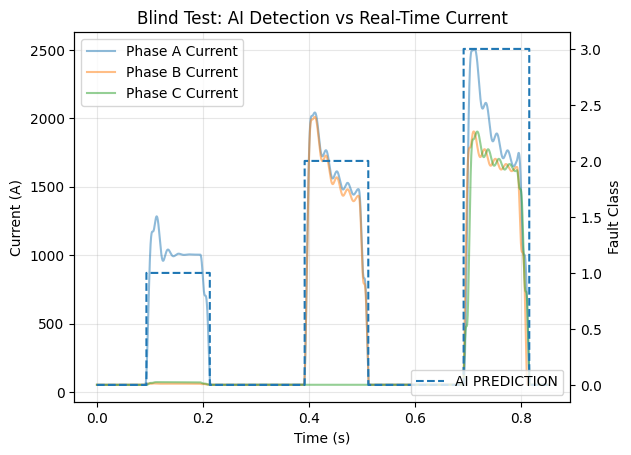

In [60]:
# TESTING PROCESS :

features = ["Va_rms","Vb_rms","Vc_rms",
            "Ia_rms","Ib_rms","Ic_rms",
            "In_rms"]

test_probs = VoltFix_AI_Model.predict_proba(df_test[features])

prob_any_fault = test_probs[:,1] + test_probs[:,2] + test_probs[:,3]
test_preds = VoltFix_AI_Model.predict(df_test[features])

test_preds[prob_any_fault > 0.1] = (np.argmax(test_probs[prob_any_fault > 0.1, 1:], 
                                    axis=1) + 1) # VERY IMP LOGIC
test_preds[prob_any_fault <= 0.1] = 0

df_test["AI_DECISION"] = test_preds

fig, ax = plt.subplots()
ax.plot(df_test["Time"], df_test["Ia_rms"], 
        label="Phase A Current", alpha=0.5)
ax.plot(df_test["Time"], df_test["Ib_rms"], 
        label="Phase B Current", alpha=0.5)
ax.plot(df_test["Time"], df_test["Ic_rms"], 
        label="Phase C Current", alpha=0.5)

ax2 = ax.twinx() 
ax2.step(df_test["Time"], df_test["AI_DECISION"],
         label="AI PREDICTION", ls = "--", where='post')

ax.set_xlabel("Time (s)")
ax.set_ylabel("Current (A)")
ax2.set_ylabel("Fault Class")

plt.title("Blind Test: AI Detection vs Real-Time Current")
ax.legend(loc='upper left')
ax2.legend(loc='lower right')
ax.grid(True,alpha = 0.3)
plt.show()


CONCLUSIONS :

- Our AI model has worked perfectly for finding the types of faults that occurs in our grid. In our simulink, we had provided LG LL and then LLL type of fault for the time seperatly.

- As shown in above figure, our AI model has successfully found the types of fault using machine learning process.

In [61]:
# SAVING MODELS

import joblib
joblib.dump(VoltFix_AI_Model,"VoltFix_AI_Model.pkl")

['VoltFix_AI_Model.pkl']

---
---
--- 